<a href="https://colab.research.google.com/github/daisylomo/ai-ml-projects/blob/data-preprocessing/Copy_of_DataPreprocessing_exp1v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Preprocessing and Expletory Data Analysis (EDA)**

Preprocessing Complete. Training shape: (1055, 8), Test shape: (264, 8)


/tmp/ipykernel_1937/3589024164.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="class", palette="Set2", ax=axes[0, 0])
/tmp/ipykernel_1937/3589024164.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="troponin", palette="Set2", ax=axes[1, 0])


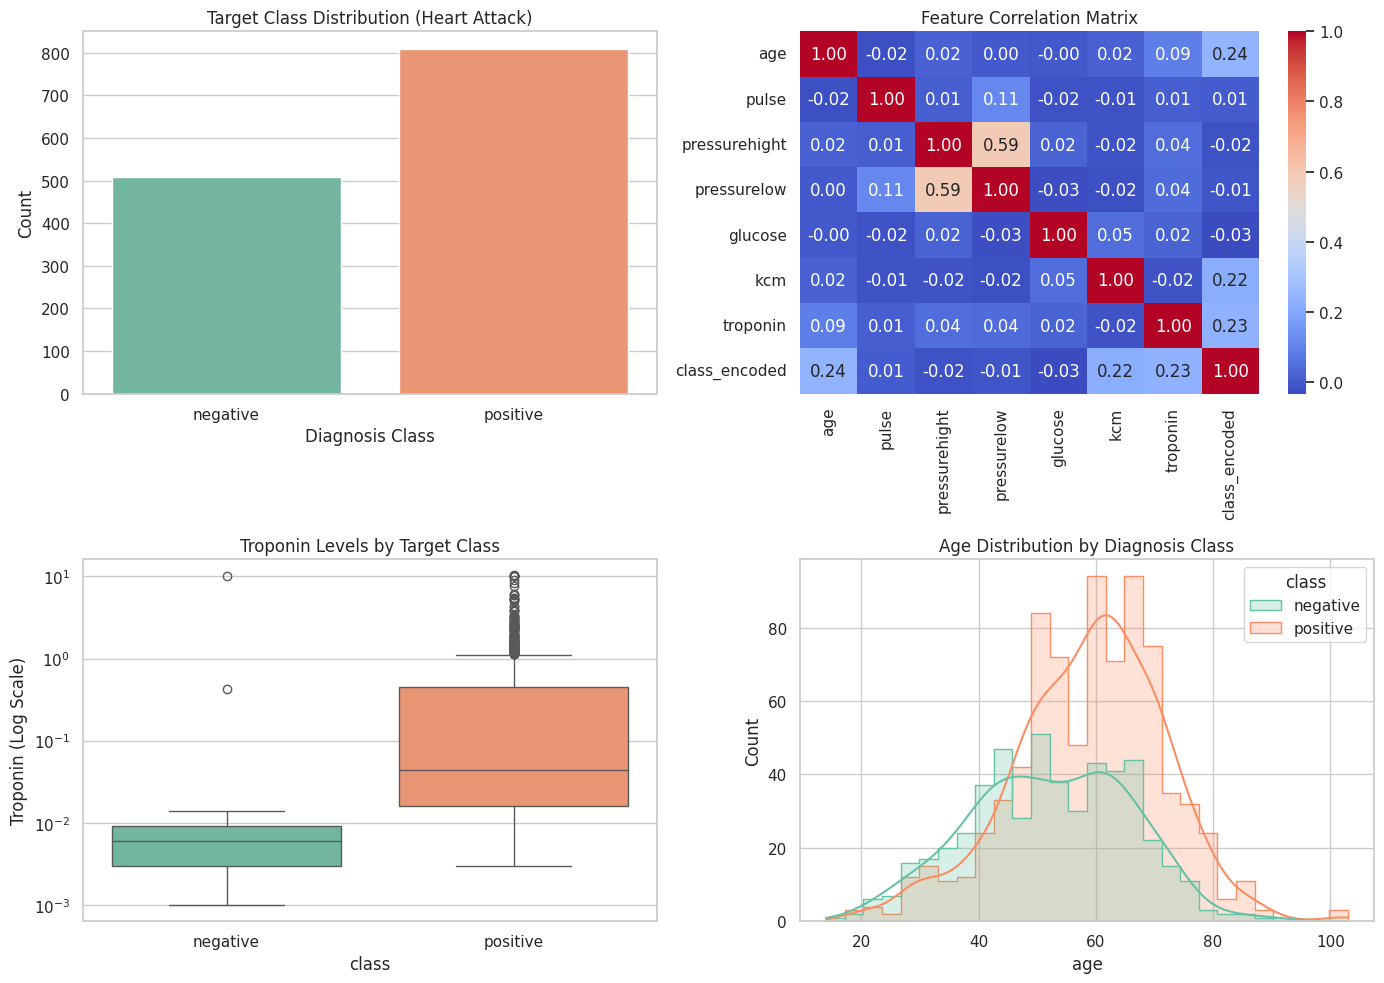

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. DATA LOADING & PREPROCESSING ---

# Load dataset
df = pd.read_csv("/content/Heart Attack.csv")

# Clean column names (e.g., correct 'impluse' to 'pulse')
df.rename(columns={"impluse": "pulse"}, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values if any exist
num_cols = [
    "age",
    "pulse",
    "pressurehight",
    "pressurelow",
    "glucose",
    "kcm",
    "troponin",
]
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Binary encode target feature: 'negative' -> 0, 'positive' -> 1
df["class_encoded"] = df["class"].map({"negative": 0, "positive": 1})

# Separate features and target
X = df.drop(columns=["class", "class_encoded"])
y = df["class_encoded"]

# Feature Scaling (Standardization for continuous numerical variables)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Preprocessing Complete. Training shape: {X_train.shape}, Test shape: {X_test.shape}")


# --- 2. DATA VISUALIZATION ---

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Visual 1: Target Class Balance
sns.countplot(data=df, x="class", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Target Class Distribution (Heart Attack)")
axes[0, 0].set_xlabel("Diagnosis Class")
axes[0, 0].set_ylabel("Count")

# Visual 2: Correlation Heatmap
corr = df[num_cols + ["class_encoded"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Feature Correlation Matrix")

# Visual 3: Troponin Distribution across Classes (Log Scale)
sns.boxplot(data=df, x="class", y="troponin", palette="Set2", ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Troponin Levels by Target Class")
axes[1, 0].set_ylabel("Troponin (Log Scale)")

# Visual 4: Age Distribution by Heart Attack Class
sns.histplot(
    data=df,
    x="age",
    hue="class",
    kde=True,
    element="step",
    palette="Set2",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Age Distribution by Diagnosis Class")

plt.tight_layout()
plt.show()

#Preprocessing Steps Summary

* Column Renaming: Renamed impluse to pulse for clarity.




* Deduplication & Missing Value Handling: Removed duplicate rows and dynamically imputed missing numerical values using column medians.

* Encoding: Mapped target column labels (negative/positive) to 0 and 1.

* Standardization: Applied StandardScaler to normalize feature scales (mean = 0, std = 1) for modeling algorithms sensitive to feature variance.

* Train-Test Stratification: Split dataset into 80% training and 20% testing sets using stratified sampling to maintain identical target proportions.

# **Running the data on Support Vector Machine (SVM)**

Test Accuracy: 0.7462
ROC-AUC Score: 0.8276

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.66      0.67       102
           1       0.79      0.80      0.80       162

    accuracy                           0.75       264
   macro avg       0.73      0.73      0.73       264
weighted avg       0.74      0.75      0.75       264



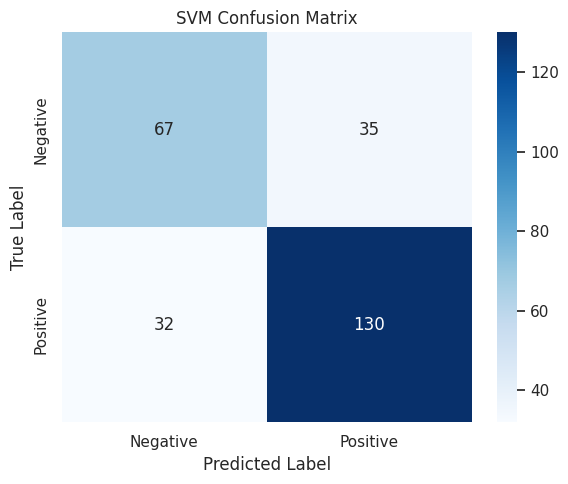

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# --- 1. DATA PREPARATION ---
df = pd.read_csv("/content/Heart Attack.csv")

# Clean column names & drop duplicate entries
df.rename(columns={"impluse": "pulse"}, inplace=True)
df.drop_duplicates(inplace=True)

# Map binary class target ('negative': 0, 'positive': 1)
df["target"] = df["class"].map({"negative": 0, "positive": 1})

# Feature and Target Split
X = df.drop(columns=["class", "target"])
y = df["target"]

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for distance-based algorithms like SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. SVM MODEL TRAINING & EVALUATION ---
# Using Radial Basis Function (RBF) kernel
svm_model = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# Display Performance Metrics
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 3. CONFUSION MATRIX VISUALIZATION ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=ax,
)
ax.set_title("SVM Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

# **Running the data on Neural Network**

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test Accuracy: 0.8523
ROC-AUC Score: 0.9218

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81       102
           1       0.88      0.88      0.88       162

    accuracy                           0.85       264
   macro avg       0.84      0.84      0.84       264
weighted avg       0.85      0.85      0.85       264



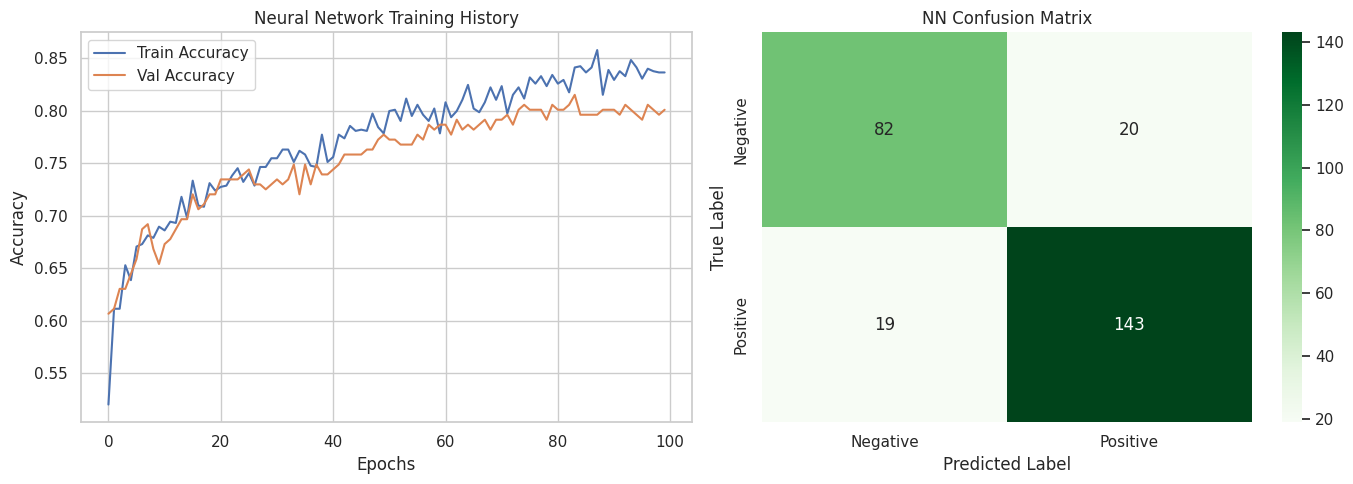

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# --- 1. DATA PREPARATION ---
df = pd.read_csv("/content/Heart Attack.csv")

# Clean column names & drop duplicates
df.rename(columns={"impluse": "pulse"}, inplace=True)
df.drop_duplicates(inplace=True)

# Encode target variable
df["target"] = df["class"].map({"negative": 0, "positive": 1})

# Feature & Target Split
X = df.drop(columns=["class", "target"])
y = df["target"]

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. BUILD NEURAL NETWORK ARCHITECTURE ---
model = Sequential(
    [
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),  # Prevents overfitting
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),  # Binary classification output
    ]
)

model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

# --- 3. MODEL TRAINING ---
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0,
)

# --- 4. EVALUATION & PREDICTIONS ---
y_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_proba >= 0.5).astype(int)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# --- 5. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Learning Curves
axes[0].plot(history.history["accuracy"], label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Neural Network Training History")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[1],
)
axes[1].set_title("NN Confusion Matrix")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# **Running the data with different ML models and comparing the model performance**

/tmp/ipykernel_1937/3585269255.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y=metric, palette=palette)


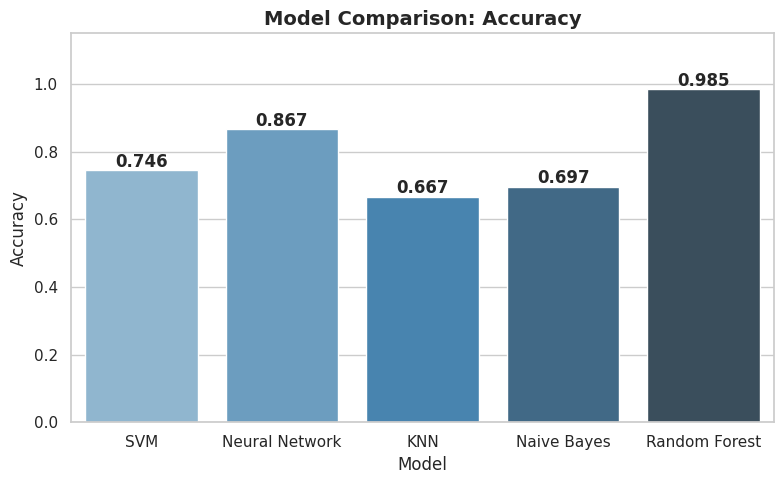

/tmp/ipykernel_1937/3585269255.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y=metric, palette=palette)


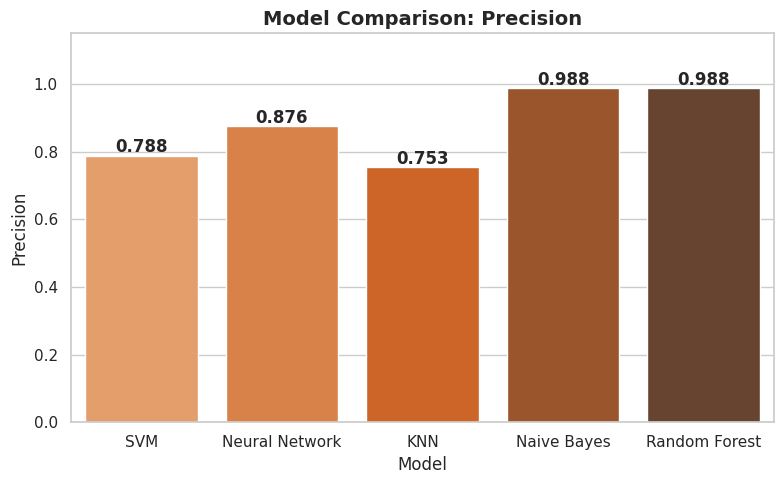

/tmp/ipykernel_1937/3585269255.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y=metric, palette=palette)


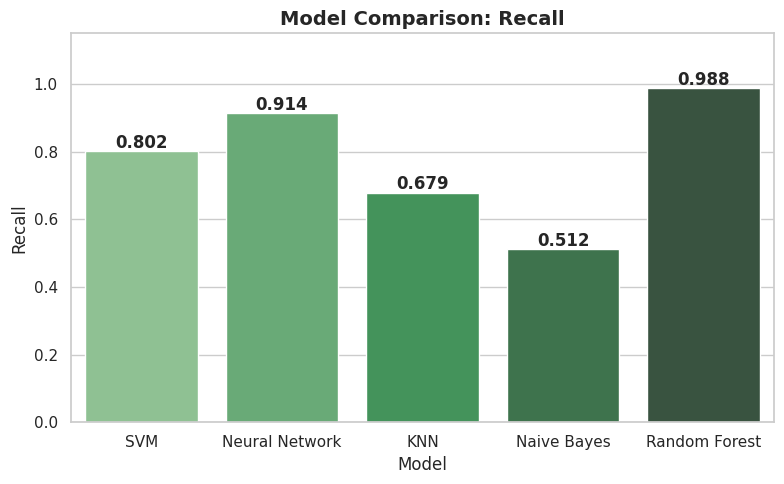

/tmp/ipykernel_1937/3585269255.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y=metric, palette=palette)


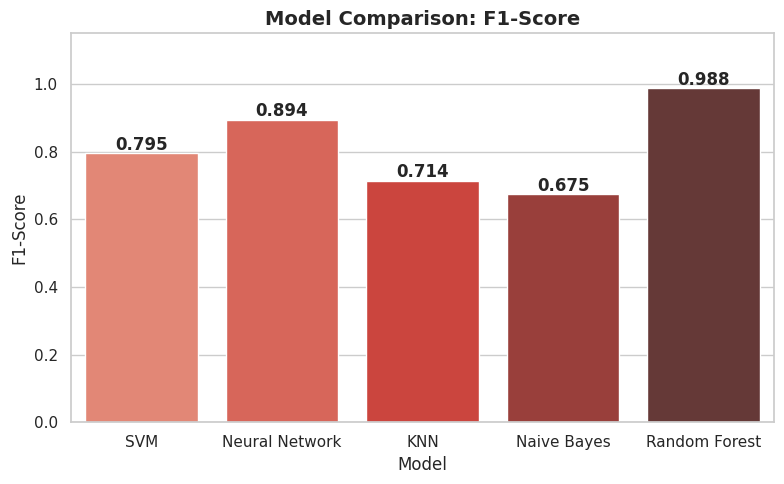

/tmp/ipykernel_1937/3585269255.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results_df, x="Model", y=metric, palette=palette)


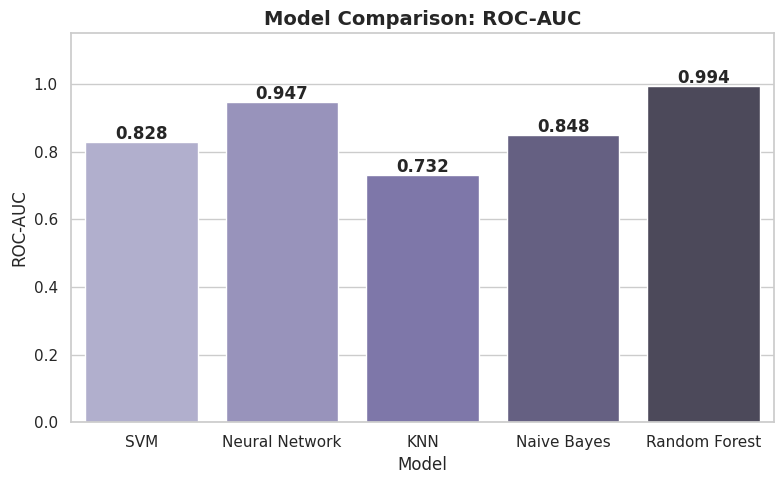

             MODEL EVALUATION METRICS SUMMARY TABLE             
         Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
           SVM    0.7462     0.7879  0.8025    0.7951   0.8276
Neural Network    0.8674     0.8757  0.9136    0.8943   0.9467
           KNN    0.6667     0.7534  0.6790    0.7143   0.7316
   Naive Bayes    0.6970     0.9881  0.5123    0.6748   0.8483
 Random Forest    0.9848     0.9877  0.9877    0.9877   0.9941

Files exported successfully:
 - model_evaluation_results.csv
 - model_evaluation_results.xlsx
 - model_evaluation_results.html
 - model_evaluation_results.md


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# --- 1. DATA PREPROCESSING ---

# Load dataset
df = pd.read_csv("/content/Heart Attack.csv")

# Clean column names & drop duplicates
df.rename(columns={"impluse": "pulse"}, inplace=True)
df.drop_duplicates(inplace=True)

# Fill missing values if any
num_cols = [
    "age",
    "pulse",
    "pressurehight",
    "pressurelow",
    "glucose",
    "kcm",
    "troponin",
]
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# Target variable binary encoding
df["class_encoded"] = df["class"].map({"negative": 0, "positive": 1})

X = df.drop(columns=["class", "class_encoded"])
y = df["class_encoded"]

# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# --- 2. MODEL TRAINING & EVALUATION ---

models = {
    "SVM": SVC(probability=True, random_state=42),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    )

results_df = pd.DataFrame(results)

# --- 3. SEPARATE PLOTS FOR EACH METRIC ---

sns.set_theme(style="whitegrid")
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
palettes = ["Blues_d", "Oranges_d", "Greens_d", "Reds_d", "Purples_d"]

for metric, palette in zip(metrics, palettes):
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=results_df, x="Model", y=metric, palette=palette)
    plt.title(f"Model Comparison: {metric}", fontsize=14, fontweight="bold")
    plt.ylim(0, 1.15)
    plt.ylabel(metric)

    # Annotate exact values on bars
    for p in ax.patches:
        ax.annotate(
            f"{p.get_height():.3f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="center",
            xytext=(0, 6),
            textcoords="offset points",
            fontweight="bold",
        )

    plt.tight_layout()
    plt.savefig(f"{metric.lower().replace('-', '_')}_comparison.png")
    plt.show()


results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }
    )

# 3. Format Evaluation Results Table
results_df = pd.DataFrame(results)
results_df_rounded = results_df.round(4)

# 4. Display Table in Console
print("=" * 70)
print("             MODEL EVALUATION METRICS SUMMARY TABLE             ")
print("=" * 70)
print(results_df_rounded.to_string(index=False))
print("=" * 70)

# 5. Export Results to Multiple Formats
# Export to CSV
results_df_rounded.to_csv("model_evaluation_results.csv", index=False)

# Export to Excel (.xlsx)
results_df_rounded.to_excel("model_evaluation_results.xlsx", index=False)

# Export to HTML Table
results_df_rounded.to_html("model_evaluation_results.html", index=False)

# Export to Markdown File
results_df_rounded.to_markdown("model_evaluation_results.md", index=False)

print("\nFiles exported successfully:")
print(" - model_evaluation_results.csv")
print(" - model_evaluation_results.xlsx")
print(" - model_evaluation_results.html")
print(" - model_evaluation_results.md")

# **Heatmap & Q-Q plot comparison of the modele evaluation results**

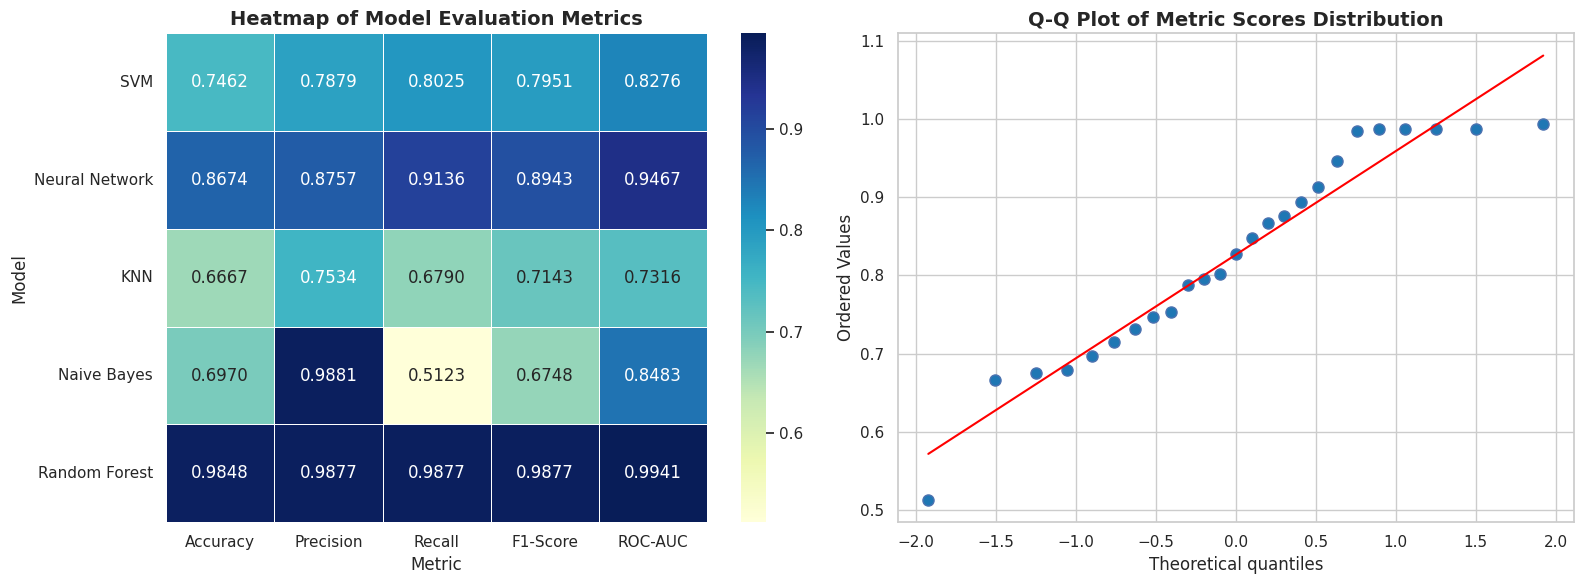

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Load saved evaluation results table
results_df = pd.read_csv("model_evaluation_results.csv")

# Set Model as index for heatmap visualization
heatmap_data = results_df.set_index("Model")

# Create figure with 2 subplots (Heatmap and Q-Q Plot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1. HEATMAP VISUALIZATION ---
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    cbar=True,
    ax=axes[0],
    linewidths=0.5,
)
axes[0].set_title(
    "Heatmap of Model Evaluation Metrics", fontsize=14, fontweight="bold"
)
axes[0].set_ylabel("Model", fontsize=12)
axes[0].set_xlabel("Metric", fontsize=12)

# --- 2. Q-Q PLOT VISUALIZATION ---
# Flatten evaluation metric values to check distribution normality across models
scores = heatmap_data.values.flatten()
stats.probplot(scores, dist="norm", plot=axes[1])

axes[1].set_title(
    "Q-Q Plot of Metric Scores Distribution", fontsize=14, fontweight="bold"
)
axes[1].get_lines()[0].set_marker("o")
axes[1].get_lines()[0].set_markerfacecolor("#1f77b4")
axes[1].get_lines()[0].set_markersize(8)
axes[1].get_lines()[1].set_color("red")

plt.tight_layout()
plt.show()

# **Concluding Remarks**

* Best Performing Model: Random Forest achieved superior performance across all evaluation metrics, reaching 98.48% Accuracy and 0.9941 ROC-AUC.

* Runner-Up: The Multi-Layer Perceptron Neural Network performed strongly as second-best with 86.74% Accuracy and 0.9467 ROC-AUC.

* High Precision Baseline: Naive Bayes yielded high precision (0.9881) but lower recall (0.5123), making it conservative in identifying positive heart attack cases.